# Sales Visualizations — Tienda

Three charts built from the combined sales dataset:
1. Revenue by product category
2. Monthly revenue trend
3. Units sold by product & month (heatmap)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path

# Create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

# Global style settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# Load and combine both datasets
df = pd.concat(
    [pd.read_csv(Path("Datos_Ventas_Tienda.csv")),
     pd.read_csv(Path("Datos_Ventas_Tienda2.csv"))],
    ignore_index=True
)

df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Mes"] = df["Fecha"].dt.month

print(f"Records loaded: {len(df):,}")

Records loaded: 1,050


## Chart 1 — Revenue by Product Category

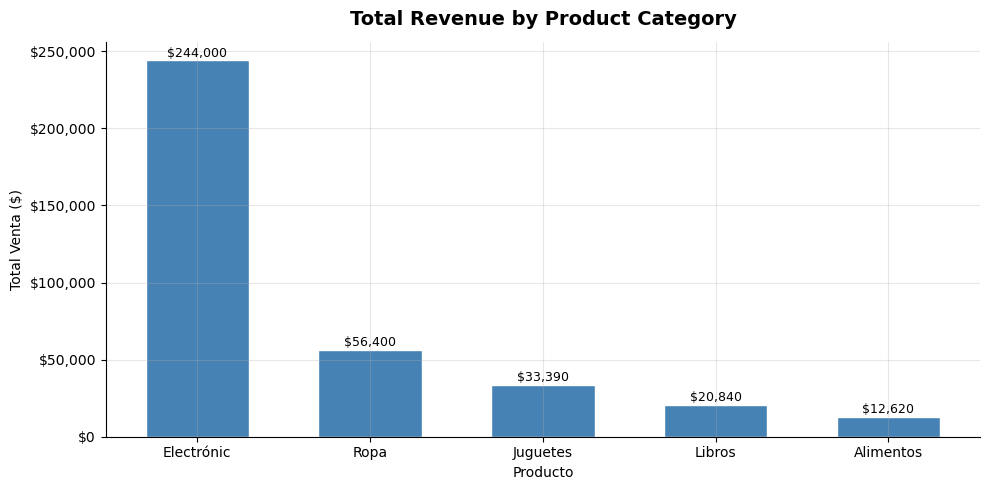

In [3]:
# Sum total revenue per product, sorted descending
revenue_by_product = (
    df.groupby("Producto")["Total Venta"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()

bars = ax.bar(
    revenue_by_product.index,
    revenue_by_product.values,
    color="steelblue",
    edgecolor="white",
    width=0.6
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"${height:,.0f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Total Revenue by Product Category", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Total Venta ($)")
ax.set_xlabel("Producto")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("charts/revenue_by_product.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2 — Monthly Revenue Trend

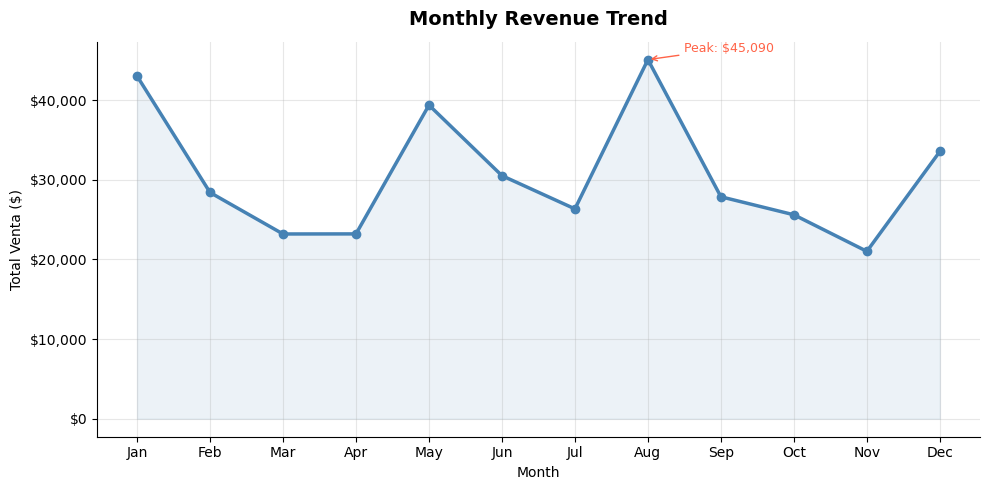

In [4]:
# Aggregate revenue by month number
monthly_revenue = (
    df.groupby("Mes")["Total Venta"]
    .sum()
    .sort_index()
)

# Map month numbers to short names for the x-axis
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
labels = [month_names[m - 1] for m in monthly_revenue.index]

fig, ax = plt.subplots()

ax.plot(
    labels,
    monthly_revenue.values,
    marker="o", linewidth=2.5, color="steelblue"
)

# Shade area under the line
ax.fill_between(labels, monthly_revenue.values, alpha=0.1, color="steelblue")

# Highlight the peak month
peak_idx = monthly_revenue.values.argmax()
ax.annotate(
    f"Peak: ${monthly_revenue.values[peak_idx]:,.0f}",
    xy=(peak_idx, monthly_revenue.values[peak_idx]),
    xytext=(peak_idx + 0.5, monthly_revenue.values[peak_idx] + 1000),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato", fontsize=9
)

ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Total Venta ($)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("charts/monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3 — Units Sold by Product & Month (Heatmap)

Shows which products sell most in which months — useful for spotting seasonal patterns.

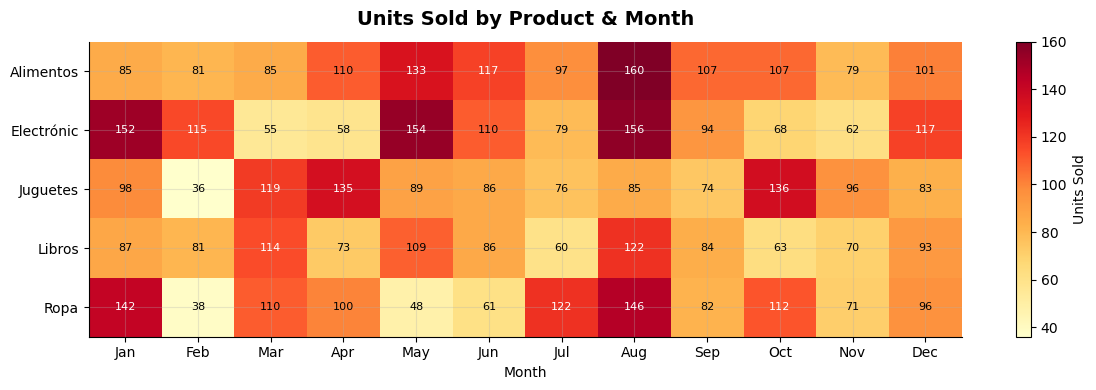

In [5]:
# Build a product × month pivot table
heatmap_data = df.pivot_table(
    index="Producto",
    columns="Mes",
    values="Cantidad",
    aggfunc="sum",
    fill_value=0
)

# Rename columns to month names
heatmap_data.columns = [month_names[m - 1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, 4))

# Heatmap with imshow
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")

# Axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Annotate each cell with its value
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=8,
                color="black" if val < heatmap_data.values.max() * 0.7 else "white")

plt.colorbar(im, ax=ax, label="Units Sold")
ax.set_title("Units Sold by Product & Month", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month")

plt.tight_layout()
plt.savefig("charts/heatmap_product_month.png", dpi=150, bbox_inches="tight")
plt.show()